In [1]:
import sys
sys.path.append("../ai-service")

import numpy as np
import torch
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from app.multimodal.model import MultimodalFusionNet

print("Student notebook environment ready")

Student notebook environment ready


In [2]:
model_path = Path("../ai-service/app/models/student/feedback_classifier_multimodal/v1/feedback_classifier_multimodal.pt")
test_path = Path("../ai-service/datasets/processed/student_feedback_multimodal_v1/test.pt")

ckpt = torch.load(model_path, map_location="cpu")
data = torch.load(test_path, map_location="cpu")

print("Checkpoint keys:", list(ckpt.keys()))
print("Num classes:", ckpt["num_classes"])
print("Samples:", len(data))
print("Sample keys:", list(data[0].keys()))

Checkpoint keys: ['state_dict', 'num_classes']
Num classes: 7
Samples: 13580
Sample keys: ['text_emb', 'ocr_emb', 'audio_emb', 'table_emb', 'mask', 'label']


In [3]:
class_names = [
    "grammar",
    "structure",
    "clarity",
    "evidence",
    "argument",
    "other",
    "style",
]

print("Class names:", class_names)

Class names: ['grammar', 'structure', 'clarity', 'evidence', 'argument', 'other', 'style']


In [4]:
model = MultimodalFusionNet(num_classes=ckpt["num_classes"])
model.load_state_dict(ckpt["state_dict"])
model.eval()

y_true = []
y_pred = []

for batch in data:
    with torch.no_grad():
        logits = model(
            batch["text_emb"].unsqueeze(0),
            batch["ocr_emb"].unsqueeze(0),
            batch["audio_emb"].unsqueeze(0),
            batch["table_emb"].unsqueeze(0),
            batch["mask"].unsqueeze(0),
        )
        pred = torch.argmax(logits, dim=1).item()

    y_pred.append(pred)
    y_true.append(int(batch["label"]))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Predictions generated:", len(y_true))
print("Unique true labels:", np.unique(y_true))
print("Unique predicted labels:", np.unique(y_pred))

Predictions generated: 13580
Unique true labels: [0 1 2 3 4 5 6]
Unique predicted labels: [0 1 2 3 4 5 6]


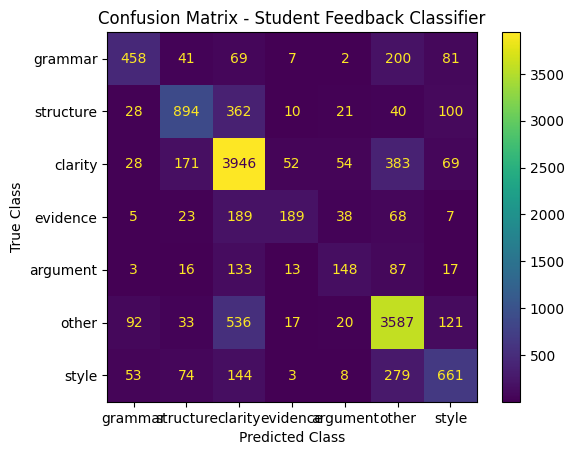

In [5]:
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot()

plt.title("Confusion Matrix - Student Feedback Classifier")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.show()

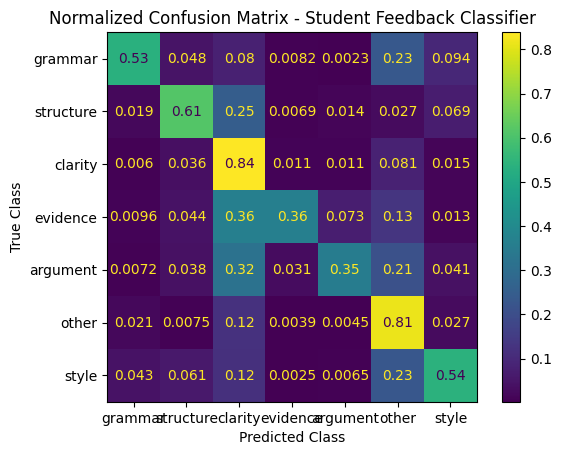

In [6]:
cm_norm = confusion_matrix(y_true, y_pred, normalize="true")
disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=class_names)
disp.plot()

plt.title("Normalized Confusion Matrix - Student Feedback Classifier")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.show()

In [7]:
print(classification_report(y_true, y_pred, target_names=class_names))

              precision    recall  f1-score   support

     grammar       0.69      0.53      0.60       858
   structure       0.71      0.61      0.66      1455
     clarity       0.73      0.84      0.78      4703
    evidence       0.65      0.36      0.47       519
    argument       0.51      0.35      0.42       417
       other       0.77      0.81      0.79      4406
       style       0.63      0.54      0.58      1222

    accuracy                           0.73     13580
   macro avg       0.67      0.58      0.61     13580
weighted avg       0.72      0.73      0.72     13580



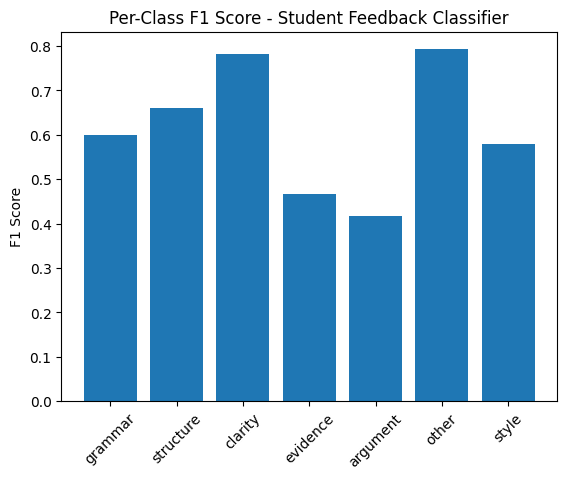

In [8]:
report_dict = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
f1_scores = [report_dict[name]["f1-score"] for name in class_names]

plt.figure()
plt.bar(class_names, f1_scores)
plt.xticks(rotation=45)
plt.ylabel("F1 Score")
plt.title("Per-Class F1 Score - Student Feedback Classifier")
plt.show()

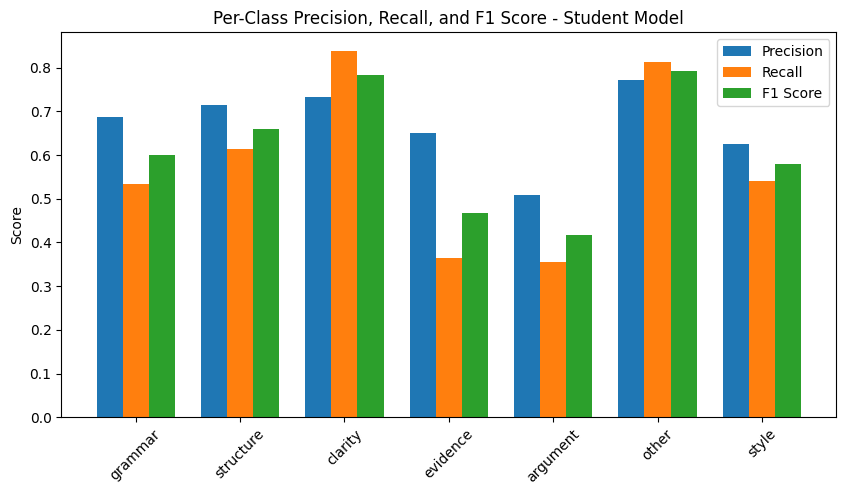

In [9]:
precision_scores = [report_dict[name]["precision"] for name in class_names]
recall_scores = [report_dict[name]["recall"] for name in class_names]
f1_scores = [report_dict[name]["f1-score"] for name in class_names]

x = np.arange(len(class_names))
width = 0.25

plt.figure(figsize=(10, 5))
plt.bar(x - width, precision_scores, width, label="Precision")
plt.bar(x, recall_scores, width, label="Recall")
plt.bar(x + width, f1_scores, width, label="F1 Score")
plt.xticks(x, class_names, rotation=45)
plt.ylabel("Score")
plt.title("Per-Class Precision, Recall, and F1 Score - Student Model")
plt.legend()
plt.show()

In [11]:
accuracy = report_dict["accuracy"]
macro_f1 = report_dict["macro avg"]["f1-score"]
weighted_f1 = report_dict["weighted avg"]["f1-score"]

print("Accuracy:", round(accuracy, 4))
print("Macro F1:", round(macro_f1, 4))
print("Weighted F1:", round(weighted_f1, 4))

Accuracy: 0.7278
Macro F1: 0.6145
Weighted F1: 0.7199


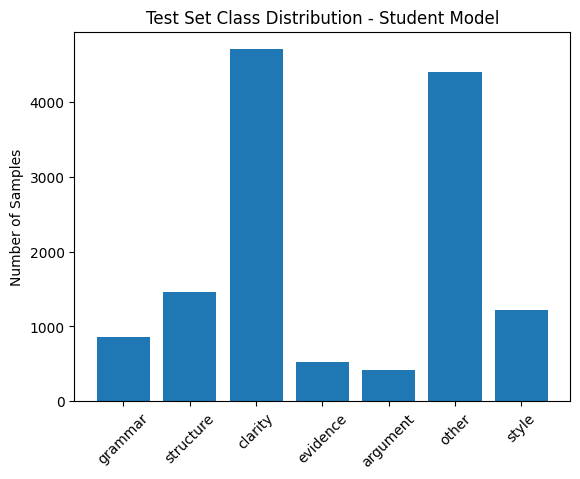

In [12]:
unique, counts = np.unique(y_true, return_counts=True)

plt.figure()
plt.bar([class_names[i] for i in unique], counts)
plt.xticks(rotation=45)
plt.ylabel("Number of Samples")
plt.title("Test Set Class Distribution - Student Model")
plt.show()

In [14]:
misclassified = (y_true != y_pred).sum()
correct = (y_true == y_pred).sum()

print("Correct predictions:", correct)
print("Misclassified predictions:", misclassified)
print("Misclassification rate:", round(misclassified / len(y_true), 4))

Correct predictions: 9883
Misclassified predictions: 3697
Misclassification rate: 0.2722


In [15]:
report_df = pd.DataFrame(report_dict).transpose()
report_df.to_csv("student_classification_report.csv")
report_df

,precision,recall,f1-score,support
grammar,0.686657,0.533800,0.600656,858.000000
structure,0.714058,0.614433,0.660510,1455.000000
clarity,0.733594,0.839039,0.782781,4703.000000
evidence,0.649485,0.364162,0.466667,519.000000
argument,0.508591,0.354916,0.418079,417.000000
other,0.772394,0.814117,0.792707,4406.000000
style,0.625947,0.540917,0.580334,1222.000000
accuracy,0.727761,0.727761,0.727761,0.727761
macro avg,0.670104,0.580198,0.614533,13580.000000
weighted avg,0.721314,0.727761,0.719897,13580.000000
